**Amazon User Segementation**

**Importing the Dependency**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

**Data collection and Analysis**

In [5]:
#loading the data
amazon_data = pd.read_csv('/content/Amazon.com cluster model.csv')

In [6]:
#read first 5 rows
amazon_data.head()

,Cus_ID,Sex,Age,Income,Rating
0,301219,M,23,53667,150
1,301220,F,32,50420,106
2,301221,M,23,62896,10
3,301222,M,32,55306,22
4,301223,F,34,20634,117


In [7]:
#finding the number of rows and columns
amazon_data.shape

(202, 5)

In [8]:
#getting some information about the data set
amazon_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Cus_ID  202 non-null    int64 
 1   Sex     202 non-null    object
 2   Age     202 non-null    int64 
 3   Income  202 non-null    int64 
 4   Rating  202 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 8.0+ KB


In [9]:
#checking the missing value
amazon_data.isnull().sum()

,0
Cus_ID,0
Sex,0
Age,0
Income,0
Rating,0


**Choosing the income column and rating column**

In [10]:
X = amazon_data.iloc[:,[3,4]].values

In [11]:
print(X)

[[53667   150]
 [50420   106]
 [62896    10]
 [55306    22]
 [20634   117]
 [49145     6]
 [42172   123]
 [68514   133]
 [31467   108]
 [64190    62]
 [35638   125]
 [56731    73]
 [29030    44]
 [55384    66]
 [59760    30]
 [63050    38]
 [59641   128]
 [67612   130]
 [21739    59]
 [68760    42]
 [30865     3]
 [25332    30]
 [41450    57]
 [22706    97]
 [37033    75]
 [62586    16]
 [55380     9]
 [55668   131]
 [63072   149]
 [34530    48]
 [60639    76]
 [28599   105]
 [27616    76]
 [68128    54]
 [69303   145]
 [25933   144]
 [21401   122]
 [48573    71]
 [27217   121]
 [61306   132]
 [69445    14]
 [57016    34]
 [39618   145]
 [47153    54]
 [39105    84]
 [33744    61]
 [54522    70]
 [56903   148]
 [31684    56]
 [26137    84]
 [25611    48]
 [47916     9]
 [31957    16]
 [56406    55]
 [64215    73]
 [21898   120]
 [25627    59]
 [24906    41]
 [69893     9]
 [67826   121]
 [54633   101]
 [46834   128]
 [37842     4]
 [24960    27]
 [68340    12]
 [35198   130]
 [65963   

**Choosing the number of clusters**

WCSS --> within cluster sum of squares

In [12]:
#finding the wcss value for different number of clusters
wcss = []

for i in range(1,11):
  kmeans = KMeans(n_clusters=i, init = 'k-means++',random_state=40)
  kmeans.fit(X)

  wcss.append(kmeans.inertia_)

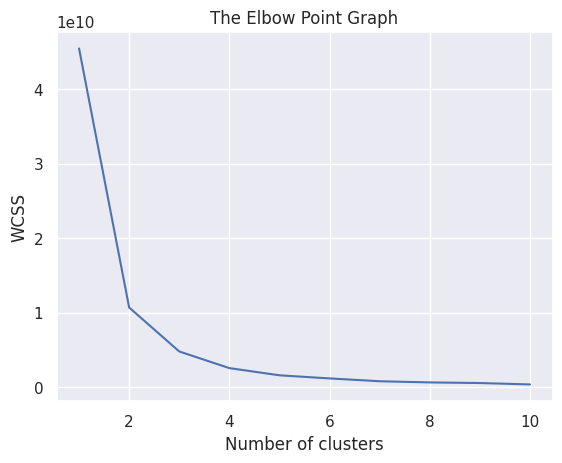

In [13]:
#plot the elbow graph
sns.set()
plt.plot(range(1,11), wcss)
plt.title('The Elbow Point Graph')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()


Optimal number of clusters = 4

**Training the model**

In [14]:
kmeans = KMeans(n_clusters=4, init='k-means++',random_state = 0)

#return a label for each data point based on their cluster

Y = kmeans.fit_predict(X)
print(Y)

[1 1 3 1 0 1 2 3 0 3 2 1 0 1 3 3 3 3 0 3 0 0 2 0 2 3 1 1 3 2 3 0 0 3 3 0 0
 1 0 3 3 1 2 1 2 2 1 1 0 0 0 1 0 1 3 0 0 0 3 3 1 1 2 0 3 2 3 0 3 2 1 2 3 1
 0 0 2 1 0 1 2 3 2 0 2 1 0 3 2 2 2 3 3 0 3 0 3 1 2 2 2 1 3 2 2 3 1 3 1 2 0
 1 2 3 3 3 2 2 1 3 1 3 1 2 1 1 1 1 2 3 2 2 3 0 3 2 1 1 0 3 1 1 0 2 0 1 1 1
 1 0 3 2 0 3 2 2 1 0 1 1 2 0 0 1 3 0 3 2 1 1 2 0 3 2 1 3 1 0 1 3 1 2 2 0 2
 2 0 1 3 2 0 3 0 3 3 0 3 0 1 2 3 0]


**Visualizing all the clusters**

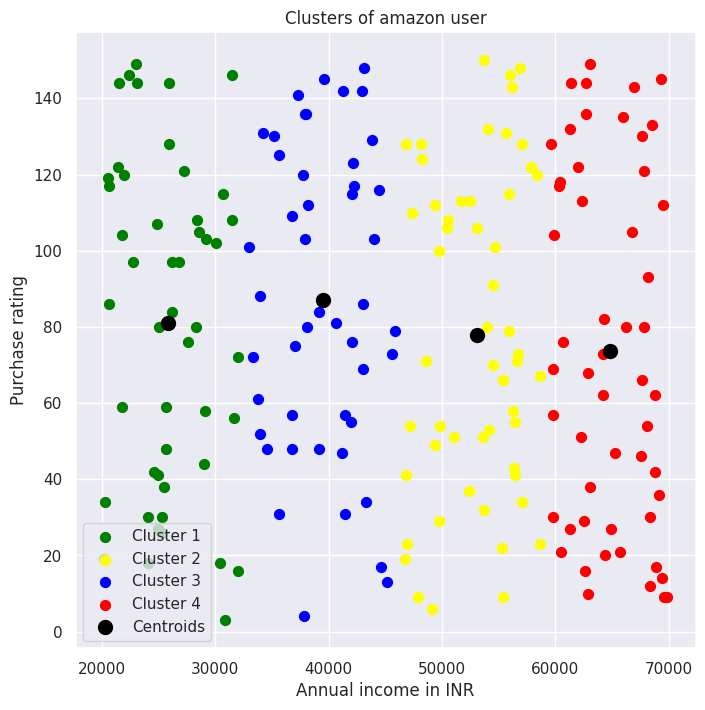

In [16]:
#ploting all the clustera and their centroids
plt.figure(figsize=(8,8))
plt.scatter(X[Y==0,0], X[Y==0,1], s=50, c='green', label='Cluster 1' )
plt.scatter(X[Y==1,0], X[Y==1,1], s=50, c='yellow', label='Cluster 2' )
plt.scatter(X[Y==2,0], X[Y==2,1], s=50, c='blue', label='Cluster 3' )
plt.scatter(X[Y==3,0], X[Y==3,1], s=50, c='red', label='Cluster 4' )

plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=100, c='black', label='Centroids')

plt.title('Clusters of amazon user')
plt.xlabel('Annual income in INR')
plt.ylabel('Purchase rating')
plt.legend()
plt.show()
